In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('../data/spacex.csv')

df.head()

,mision,fecha,exito
0,FalconSat,2006-03-24T22:30:00.000Z,False
1,DemoSat,2007-03-21T01:10:00.000Z,False
2,Trailblazer,2008-08-03T03:34:00.000Z,False
3,RatSat,2008-09-28T23:15:00.000Z,True
4,RazakSat,2009-07-13T03:35:00.000Z,True


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   mision  205 non-null    str   
 1   fecha   205 non-null    str   
 2   exito   186 non-null    object
dtypes: object(1), str(2)
memory usage: 4.9+ KB


In [4]:
df['exito'].value_counts()

exito
True     181
False      5
Name: count, dtype: int64

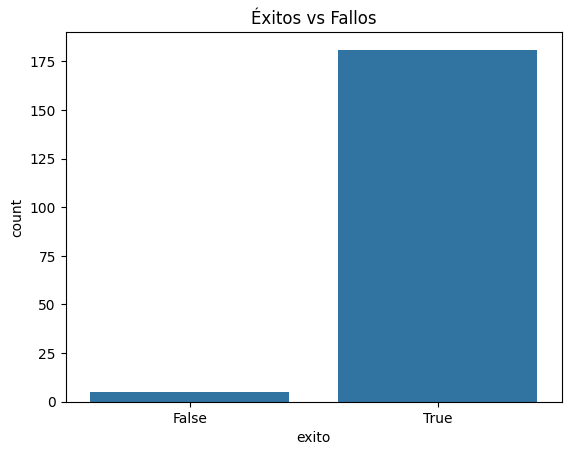

In [5]:
sns.countplot(x='exito', data=df)
plt.title("Éxitos vs Fallos")
plt.show()

In [6]:
df['fecha'] = pd.to_datetime(df['fecha'])
df['año'] = df['fecha'].dt.year

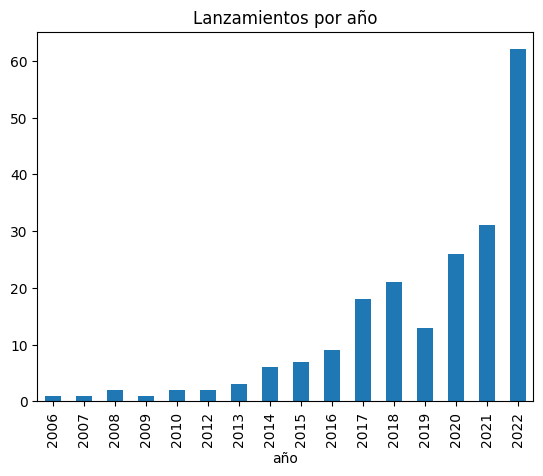

In [7]:
df['año'].value_counts().sort_index().plot(kind='bar')
plt.title("Lanzamientos por año")
plt.show()

In [8]:
from sklearn.model_selection import train_test_split

# Convertir exito a número (True=1, False=0)
df['exito'] = df['exito'].astype(int)

# Variables
X = df[['año']]
y = df['exito']

# Dividir datos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

ValueError: cannot convert float NaN to integer

In [ ]:
from sklearn.model_selection import train_test_split

# Convertir exito correctamente
df['exito'] = df['exito'].astype(str).map({'True': 1, 'False': 0})

# Variables
X = df[['año']]
y = df['exito']

# Dividir datos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.linear_model import LogisticRegression

modelo = LogisticRegression()
modelo.fit(X_train, y_train)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Convertir exito bien
df['exito'] = df['exito'].astype(str).map({'True': 1, 'False': 0})

# Eliminar nulos otra vez por seguridad
df = df.dropna()

# Variables
X = df[['año']]
y = df['exito']

# División
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Modelo
modelo = LogisticRegression()
modelo.fit(X_train, y_train)

print("Modelo entrenado correctamente 🚀")

In [ ]:
print(X_train.shape)
print(y_train.shape)
print(y_train.value_counts())

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Convertir fecha
df['fecha'] = pd.to_datetime(df['fecha'], errors='coerce')
df['año'] = df['fecha'].dt.year

# Convertir exito
df['exito'] = df['exito'].astype(str).map({'True': 1, 'False': 0})

# Eliminar solo lo necesario
df = df.dropna(subset=['exito', 'año'])

# Variables
X = df[['año']]
y = df['exito']

# División
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Modelo
modelo = LogisticRegression()
modelo.fit(X_train, y_train)

print("Modelo entrenado correctamente 🚀")

In [ ]:
print(df.shape)
print(df.head())

In [ ]:
print(df['exito'].unique())

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Convertir fecha
df['fecha'] = pd.to_datetime(df['fecha'], errors='coerce')
df['año'] = df['fecha'].dt.year

# Convertir exito BIEN
df['exito'] = df['exito'].apply(lambda x: 1 if x == True else 0)

# Eliminar solo lo necesario
df = df.dropna(subset=['año'])

# Variables
X = df[['año']]
y = df['exito']

# División
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Modelo
modelo = LogisticRegression()
modelo.fit(X_train, y_train)

print("Modelo entrenado correctamente 🚀")

In [ ]:
import pandas as pd

df = pd.read_csv('../data/spacex.csv')

print(df.shape)
df.head()

In [ ]:
# Convertir fecha
df['fecha'] = pd.to_datetime(df['fecha'], errors='coerce')

# Crear año
df['año'] = df['fecha'].dt.year

# Convertir exito correctamente
df['exito'] = df['exito'].apply(lambda x: 1 if x == True else 0)

# Eliminar solo filas necesarias
df = df.dropna(subset=['año'])

print(df.shape)

In [ ]:
print(df['exito'].value_counts())
print(df.head())

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix

y_pred = modelo.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred))


In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix

y_pred = modelo.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred))